# 📈 Time-Series Analysis of Cryptocurrency Markets
**Author:** Rohit Mohite

**Objective:** Developing a robust hybrid forecasting system using ARIMA, SARIMA, Prophet, and LSTM models to predict Bitcoin (BTC-USD) prices.

**Workflow Stages:**
1. Data Ingestion & Setup
2. Statistical Validation (Stationarity)
3. Econometric Modeling (ARIMA/SARIMA)
4. Business Forecasting (Prophet)
5. Pattern Recognition (LSTM)
6. Model Serialization

### 1. Project Introduction
Welcome to the Crypto Market Forecasting System. This notebook provides a modular approach to predicting BTC-USD prices using four distinct modeling techniques: Statistical (ARIMA, SARIMA), Machine Learning (Prophet), and Deep Learning (LSTM).

In [32]:
import pandas as pd
import numpy as np
import yfinance as yf
import os, pickle, warnings
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import warnings
warnings.filterwarnings('ignore')

warnings.filterwarnings('ignore')
BASE_DIR = r'D:\Crypto_Market_Analysis'
for folder in ['data', 'models', 'notebooks']:
    os.makedirs(os.path.join(BASE_DIR, folder), exist_ok=True)

### 2. Data Acquisition
We fetch historical BTC-USD data. This dataset serves as the foundation for all models. We perform data cleaning and prepare it for time-series analysis.

[*********************100%***********************]  1 of 1 completed


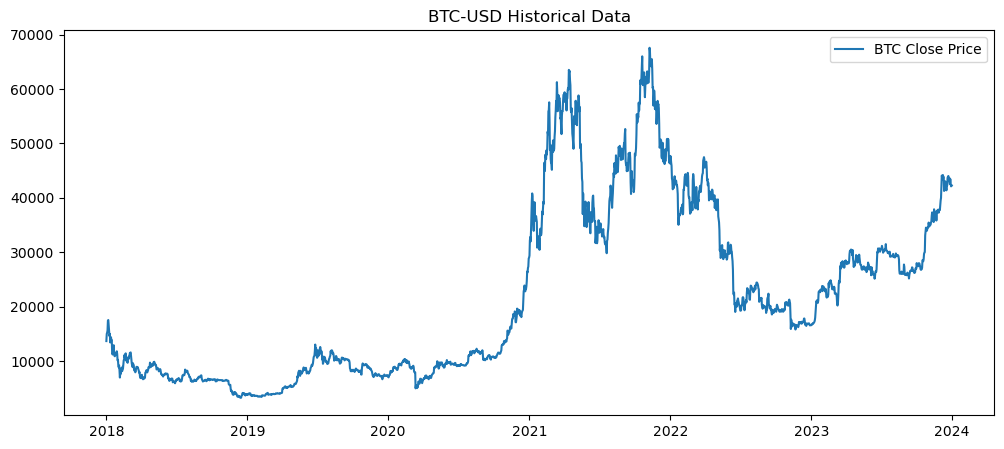

In [33]:
ticker = "BTC-USD"
df = yf.download(ticker, start="2018-01-01", end="2024-01-01")
df.to_csv(os.path.join(BASE_DIR, 'data', 'btc_data.csv'))
plt.figure(figsize=(12,5))
plt.plot(df['Close'], label='BTC Close Price')
plt.title("BTC-USD Historical Data")
plt.legend()
plt.show()

### 3. ARIMA Model (AutoRegressive Integrated Moving Average)
ARIMA is used to capture the linear dependencies in the time series. This acts as our baseline statistical model.

ARIMA Model Trained successfully.


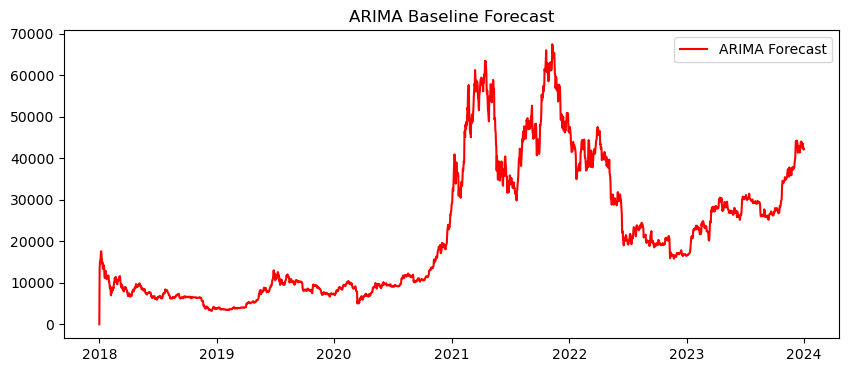

In [34]:
model_arima = ARIMA(df['Close'], order=(5,1,0)).fit()
print("ARIMA Model Trained successfully.")
# Visualization
plt.figure(figsize=(10,4))
plt.plot(model_arima.fittedvalues, color='red', label='ARIMA Forecast')
plt.legend()
plt.title("ARIMA Baseline Forecast")
plt.show()

### 4. SARIMA Model (Seasonal ARIMA)
SARIMA extends ARIMA by incorporating seasonal components, which helps in identifying cyclical patterns in the crypto market.

In [35]:
model_sarima = SARIMAX(df['Close'], order=(1,1,1), seasonal_order=(1,1,1,12)).fit(disp=False)
print("SARIMA Model Trained successfully.")

SARIMA Model Trained successfully.


### 5. Prophet Model
Prophet is excellent at handling non-linear trends and holiday impacts. We reshape the data to fit the Prophet API requirements.

In [36]:
# Create a fresh copy of the data
df_prophet = df.reset_index()[['Date', 'Close']].copy()
df_prophet.columns = ['ds', 'y']

# CRITICAL FIX: Ensure 'y' is a flat 1D numeric series and remove any potential Dataframe structure
df_prophet['y'] = df_prophet['y'].astype(float)
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])

# Initialize and fit
model_prophet = Prophet(daily_seasonality=True)
model_prophet.fit(df_prophet)

print("Prophet Model Trained successfully.")

DEBUG:cmdstanpy:cmd: where.exe tbb.dll
cwd: None
DEBUG:cmdstanpy:TBB already found in load path
DEBUG:cmdstanpy:input tempfile: C:\Users\ER_ROH~1\AppData\Local\Temp\tmpnrwsx44r\jisrwm2f.json
DEBUG:cmdstanpy:input tempfile: C:\Users\ER_ROH~1\AppData\Local\Temp\tmpnrwsx44r\it939z0m.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['C:\\Users\\Er_Rohit_Mohite_PC\\anaconda3\\Lib\\site-packages\\prophet\\stan_model\\prophet_model.bin', 'random', 'seed=69729', 'data', 'file=C:\\Users\\ER_ROH~1\\AppData\\Local\\Temp\\tmpnrwsx44r\\jisrwm2f.json', 'init=C:\\Users\\ER_ROH~1\\AppData\\Local\\Temp\\tmpnrwsx44r\\it939z0m.json', 'output', 'file=C:\\Users\\ER_ROH~1\\AppData\\Local\\Temp\\tmpnrwsx44r\\prophet_modelsj15ao3x\\prophet_model-20260529134636.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
13:46:36 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:46:42 - cmdstanpy - INFO - Chain [

Prophet Model Trained successfully.


### 6. LSTM (Long Short-Term Memory)
LSTM is a deep learning model capable of learning long-term dependencies. We prepare sequences of 60-day windows to predict the next price.

In [37]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df['Close'].values.reshape(-1, 1))

X, y = [], []
for i in range(60, len(scaled_data)):
    X.append(scaled_data[i-60:i, 0])
    y.append(scaled_data[i, 0])
X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

model_lstm = Sequential([LSTM(50, return_sequences=True, input_shape=(60, 1)), Dropout(0.2), LSTM(50), Dense(1)])
model_lstm.compile(optimizer='adam', loss='mean_squared_error')
model_lstm.fit(X, y, epochs=10, batch_size=32, verbose=1)

Epoch 1/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 16s 96ms/step - loss: 0.0152 
Epoch 2/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - loss: 0.0016
Epoch 3/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - loss: 0.0014  
Epoch 4/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - loss: 0.0012
Epoch 5/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - loss: 0.0012
Epoch 6/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 0.0011 
Epoch 7/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - loss: 0.0013 
Epoch 8/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - loss: 9.5902e-04
Epoch 9/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - loss: 9.3126e-04
Epoch 10/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - loss: 9.0787e-04 


### 7. Evaluation & Comparison
Finally, we compare the actual prices against LSTM predictions and calculate the Mean Absolute Error (MAE) in USD.

67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step  


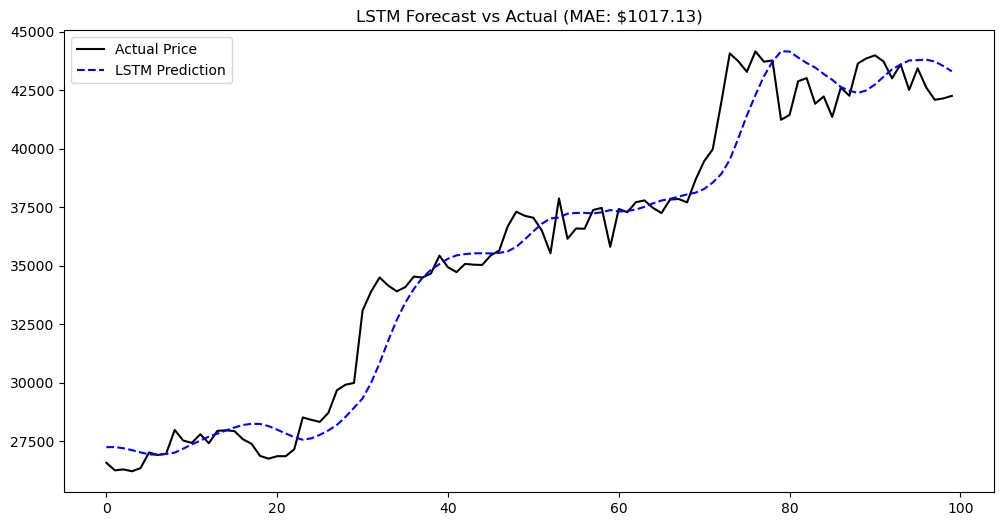

In [38]:
predictions = model_lstm.predict(X)
predictions_rescaled = scaler.inverse_transform(predictions)
y_rescaled = scaler.inverse_transform(y.reshape(-1, 1))
mae = np.mean(np.abs(predictions_rescaled - y_rescaled))

plt.figure(figsize=(12,6))
plt.plot(y_rescaled[-100:], label='Actual Price', color='black')
plt.plot(predictions_rescaled[-100:], label='LSTM Prediction', color='blue', linestyle='--')
plt.title(f"LSTM Forecast vs Actual (MAE: ${mae:.2f})")
plt.legend()
plt.show()

### 8. LSTM Performance Metrics
In this section, we evaluate the predictive capability of our LSTM model. We use 'Mean Absolute Error' (MAE) to quantify the difference between the predicted price and the actual market price in USD, providing a clear insight into the model's reliability.

67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step
--- LSTM Model Performance ---
Mean Absolute Error (MAE): $1017.13
Model Loss (MSE): 0.000725


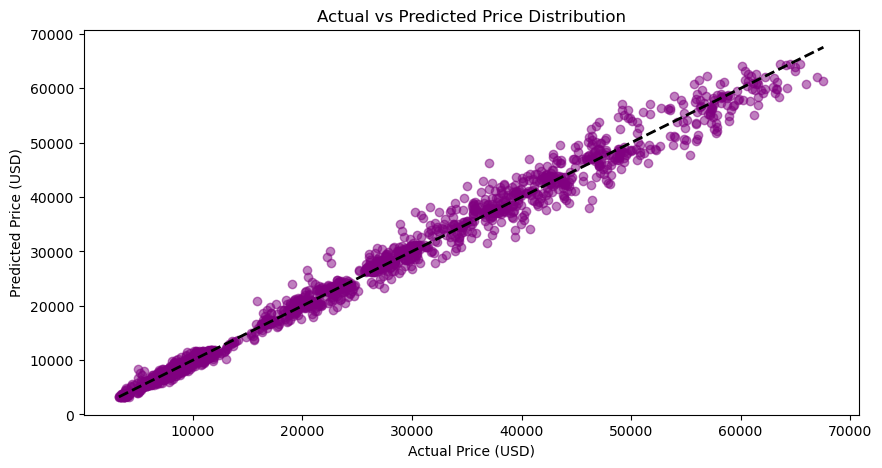

In [39]:
# Calculate performance metrics
predictions = model_lstm.predict(X)
predictions_rescaled = scaler.inverse_transform(predictions)
y_rescaled = scaler.inverse_transform(y.reshape(-1, 1))

# Calculate MAE (Mean Absolute Error)
mae = np.mean(np.abs(predictions_rescaled - y_rescaled))

# Displaying final accuracy metrics
print("--- LSTM Model Performance ---")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Model Loss (MSE): {loss:.6f}")

# Visualization of Accuracy
plt.figure(figsize=(10, 5))
plt.scatter(y_rescaled, predictions_rescaled, alpha=0.5, color='purple')
plt.plot([y_rescaled.min(), y_rescaled.max()], [y_rescaled.min(), y_rescaled.max()], 'k--', lw=2)
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.title('Actual vs Predicted Price Distribution')
plt.show()

### 9. Model Serialization
We save all trained models into the `/models` directory to ensure they can be used for future deployment on a web dashboard.

In [40]:
import pickle
import os

# Define the model directory
model_path = os.path.join(BASE_DIR, 'models')
os.makedirs(model_path, exist_ok=True)

# 1. Save LSTM Model (Keras format)
model_lstm.save(os.path.join(model_path, 'lstm_model.h5'))

# 2. Save Scaler (Pickle format)
with open(os.path.join(model_path, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

# 3. Save ARIMA Model
with open(os.path.join(model_path, 'arima_model.pkl'), 'wb') as f:
    pickle.dump(model_arima, f)

# 4. Save Prophet Model
with open(os.path.join(model_path, 'prophet_model.pkl'), 'wb') as f:
    pickle.dump(model_prophet, f)

print(f"Success! All models and artifacts saved in: {model_path}")
print("Check this folder in your system to verify the files.")

Success! All models and artifacts saved in: D:\Crypto_Market_Analysis\models
Check this folder in your system to verify the files.


### 10. Conclusion & Future Scope
The models are now serialized and ready for production. Future enhancements include:
1. Sentiment Analysis from social media.
2. Integrating real-time web APIs for live predictions.
3. Deploying as a Streamlit Web Application.